In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Student Mental health.csv")
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:06,Female,21.0,Engineering,year 3,3.00 - 3.49,Yes,Yes,No,No,No
1,8/7/2020 12:39,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No
2,8/7/2020 12:39,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No
3,8/7/2020 12:39,Female,21.0,Psychology,year 1,3.50 - 4.00,No,No,Yes,No,No
4,8/7/2020 14:29,Male,18.0,BCS,year 1,3.50 - 4.00,No,Yes,No,Yes,No


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     505 non-null    object 
 1   Choose your gender                            505 non-null    object 
 2   Age                                           492 non-null    float64
 3   What is your course?                          505 non-null    object 
 4   Your current year of Study                    505 non-null    object 
 5   What is your CGPA?                            505 non-null    object 
 6   Marital status                                505 non-null    object 
 7   Do you have Depression?                       505 non-null    object 
 8   Do you have Anxiety?                          505 non-null    object 
 9   Do you have Panic attack?                     505 non-null    obj

Timestamp                                        0
Choose your gender                               0
Age                                             13
What is your course?                             0
Your current year of Study                       0
What is your CGPA?                               0
Marital status                                   0
Do you have Depression?                          0
Do you have Anxiety?                             0
Do you have Panic attack?                        0
Did you seek any specialist for a treatment?     0
dtype: int64

In [4]:
df.dropna(inplace=True)

In [5]:
df['Choose your gender'] = df['Choose your gender'].map({'Male':0, 'Female':1})

df['Do you have Depression?'] = df['Do you have Depression?'].map({'Yes':1, 'No':0})
df['Do you have Anxiety?'] = df['Do you have Anxiety?'].map({'Yes':1, 'No':0})
df['Do you have Panic attack?'] = df['Do you have Panic attack?'].map({'Yes':1, 'No':0})

In [6]:
df['What is your CGPA?'] = df['What is your CGPA?'].astype(str)
df['What is your CGPA?'] = df['What is your CGPA?'].apply(lambda x: float(x.split('-')[0].strip()))

In [7]:
print(df.columns)

Index(['Timestamp', 'Choose your gender', 'Age', 'What is your course?',
       'Your current year of Study', 'What is your CGPA?', 'Marital status',
       'Do you have Depression?', 'Do you have Anxiety?',
       'Do you have Panic attack?',
       'Did you seek any specialist for a treatment?'],
      dtype='object')


In [8]:
df.columns = df.columns.str.strip()

In [9]:
df.drop(['Timestamp', 'What is your course?', 'Your current year of Study'], axis=1, inplace=True, errors='ignore')

In [10]:
# First, check the actual column names in your DataFrame
print(df.columns.tolist())

# Then drop the columns using the correct column names
# For example, if the actual names are slightly different:

# Alternatively, if you're unsure about exact names, you can use a safer approach:
# This will only drop columns that exist in the DataFrame
columns_to_drop = ['Timestamp', 'What is your course?', 'Your current year of Study']
existing_columns = [col for col in columns_to_drop if col in df.columns]
df.drop(existing_columns, axis=1, inplace=True)

['Choose your gender', 'Age', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']


In [11]:
df['Marital status'] = df['Marital status'].map({'No':0, 'Yes':1})

df['Did you seek any specialist for a treatment?'] = df['Did you seek any specialist for a treatment?'].map({'No':0, 'Yes':1})

In [12]:
X = df.drop('Do you have Depression?', axis=1)
y = df['Do you have Depression?']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced',n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [15]:
y_pred = model.predict(X_test)


In [16]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8282828282828283


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.96      0.88        68
           1       0.85      0.55      0.67        31

    accuracy                           0.83        99
   macro avg       0.84      0.75      0.78        99
weighted avg       0.83      0.83      0.82        99



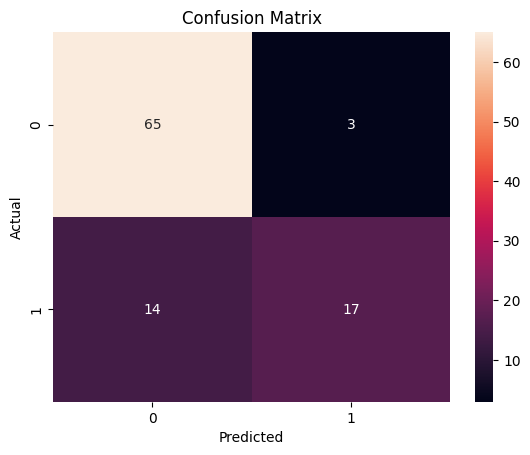

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

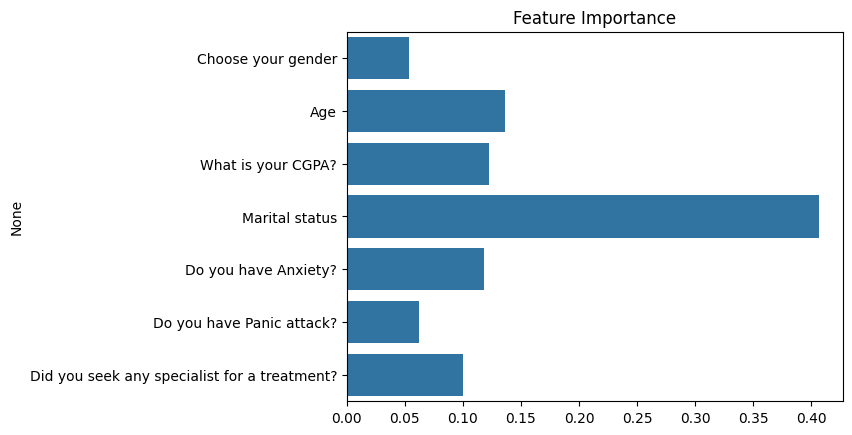

In [19]:
importances = model.feature_importances_

sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importance")
plt.show()

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_scaled, y, cv=5)

print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.83838384 0.75757576 0.78571429 0.86734694 0.84693878]
Average accuracy: 0.8191919191919192


In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7878787878787878


In [22]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Random Forest Accuracy: 0.8282828282828283
Logistic Regression Accuracy: 0.7878787878787878


In [23]:
import pickle

pickle.dump(model, open("mental_health_model.pkl", "wb"))